异质性检测

==== 实验A: 异质初始人口 ====
初始人口: [100 110 121 132 142 153 164 175 185 196 207 217 228 239 250]


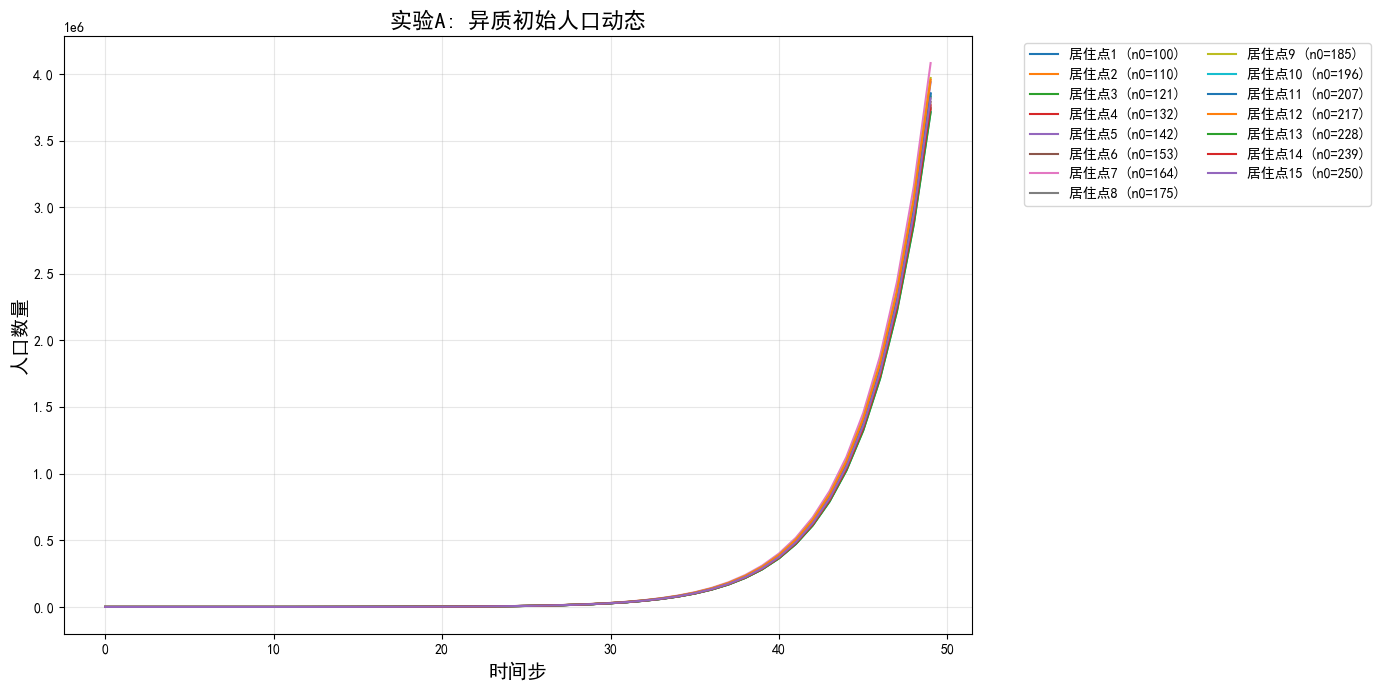


==== 实验B: 异质迁移率 ====
迁移率: [0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65 0.7  0.75 0.8  0.85
 0.9 ]


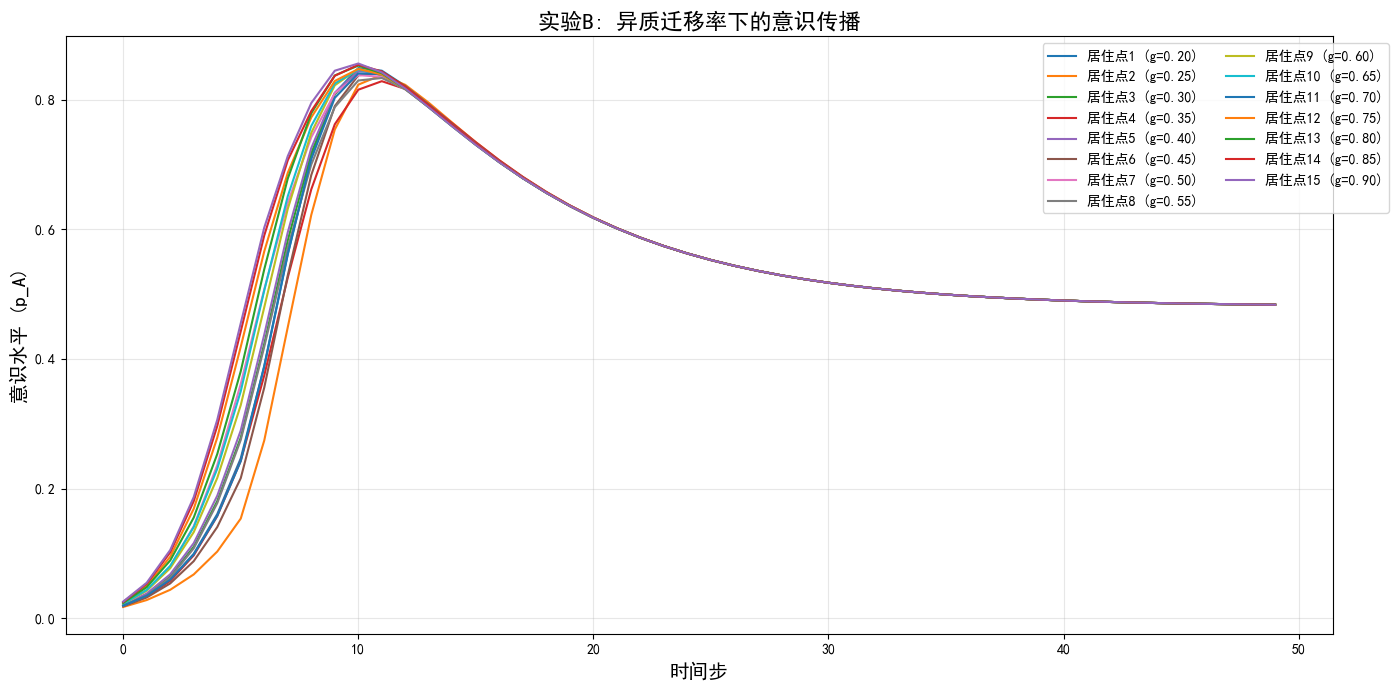

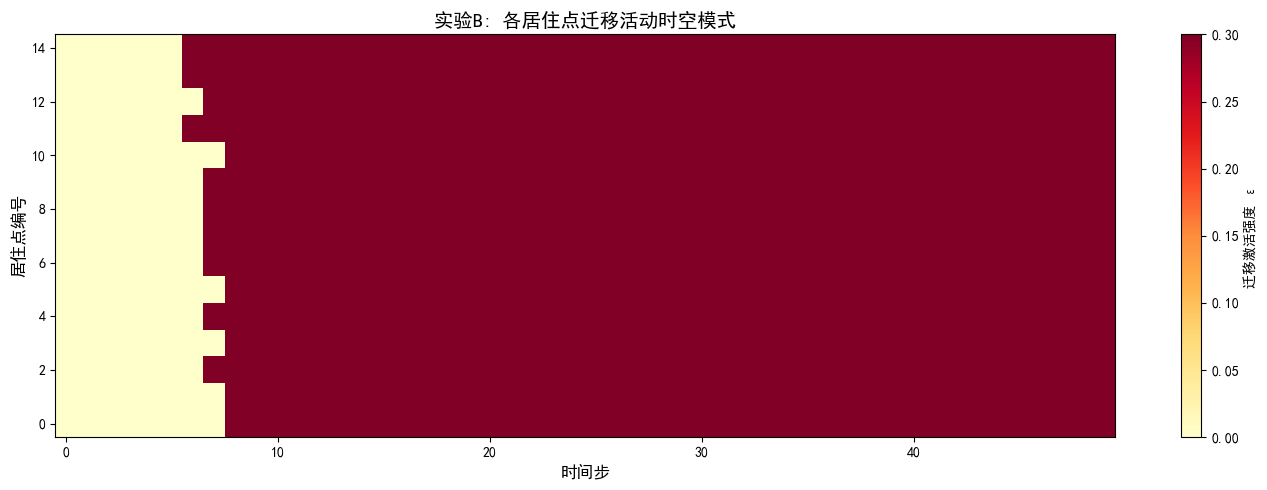

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
from matplotlib import rcParams

# 设置中文显示
rcParams['font.sans-serif'] = ['SimHei']
rcParams['axes.unicode_minus'] = False

# ========================
# 核心函数定义
# ========================

def compute_epsilon(states, alpha, epsilon0):
    """计算激活因子epsilon_i"""
    p_A = states[:, 1] + states[:, 2] + states[:, 4]  # AS + AI + AR
    return np.where(p_A > alpha, epsilon0, 0.0)

def compute_effective_awareness(n, states, g_i, R):
    """计算中转站的有效意识水平"""
    N, M = R.shape
    tilde_p_A = np.zeros(M)
    p_A_res = states[:, 1] + states[:, 2] + states[:, 4]
    
    for j in range(M):
        numerator = np.sum(n * g_i * R[:, j] * p_A_res)
        denominator = np.sum(n * g_i * R[:, j])
        tilde_p_A[j] = numerator / denominator if denominator > 0 else 0
    return tilde_p_A

def compute_infection_residence(n, states, g_i, beta_U, beta_A):
    """计算居住点内部感染概率"""
    n_remain = n * (1 - g_i)
    p_I = states[:, 2]
    N_U = 1 - np.power(1 - beta_U * p_I, n_remain)
    N_A = 1 - np.power(1 - beta_A * p_I, n_remain)
    return N_U, N_A

def compute_infection_transit(n, states, g_i, R, beta_U, beta_A):
    """计算中转站感染概率"""
    N, M = R.shape
    M_U, M_A = np.zeros(M), np.zeros(M)
    for j in range(M):
        p_inf_U = 1.0
        p_inf_A = 1.0
        for k in range(N):
            n_kj = n[k] * g_i[k] * R[k, j]
            p_I = states[k, 2]
            p_inf_U *= (1 - beta_U * p_I) ** n_kj
            p_inf_A *= (1 - beta_A * p_I) ** n_kj
        M_U[j] = 1 - p_inf_U
        M_A[j] = 1 - p_inf_A
    return M_U, M_A

def update_states(states, r, Q_U, Q_A, mu1, mu2):
    """完整状态更新方程"""
    new_states = np.zeros_like(states)
    US, AS, AI, UR, AR = states[:, 0], states[:, 1], states[:, 2], states[:, 3], states[:, 4]
    
    new_states[:, 0] = US*(1-r)*(1-Q_U) + AS*mu1*(1-Q_U)  # US
    new_states[:, 1] = AS*(1-mu1)*(1-Q_A) + US*r*(1-Q_A)  # AS
    new_states[:, 2] = (AI*(1-mu2) + AS*(1-mu1)*Q_A + 
                       AS*mu1*Q_U + US*(1-r)*Q_U + US*r*Q_A)  # AI
    new_states[:, 3] = AI*mu1*mu2 + AR*mu1 + UR*(1-r)  # UR
    new_states[:, 4] = AR*(1-mu1) + AI*(1-mu1)*mu2 + UR*r  # AR
    
    # 归一化
    row_sums = new_states.sum(axis=1)
    return new_states / row_sums[:, np.newaxis]

def update_population(n, states, g_i, epsilon, R, T):
    """修正版人口更新函数"""
    N, M = R.shape
    F = n * g_i * epsilon
    
    # 剩余人口和状态
    X = states * n[:, np.newaxis]
    X_remain = X - (X.T * (g_i * epsilon)).T
    n_remain = n - F
    
    # 计算中转站流入
    m = np.zeros(M)
    m_X = np.zeros((M, 5))
    for j in range(M):
        for i in range(N):
            flow = n[i] * g_i[i] * epsilon[i] * R[i, j]
            m[j] += flow
            m_X[j] += X[i] * g_i[i] * epsilon[i] * R[i, j]
    
    # 计算返回人口（修正维度问题）
    flow_return = np.zeros(N)
    flow_return_X = np.zeros((N, 5))
    for j in range(M):
        for i in range(N):
            flow_return[i] += m[j] * T[j, i]  # 注意T的维度是M×N
            flow_return_X[i] += m_X[j] * T[j, i]
    
    # 更新人口和状态
    n_new = n_remain + flow_return
    X_new = X_remain + flow_return_X
    new_states = X_new / np.clip(n_new[:, np.newaxis], 1e-10, None)
    
    return n_new, new_states

def main_simulation(Time, N, M, params, n_init, g_i=None):
    """修正版主仿真函数"""
    # 初始化状态
    states = np.zeros((N, 5))
    states[:, 0] = 0.99  # US
    states[:, 2] = 0.01   # AI
    n = n_init.copy()
    
    # 创建迁移矩阵（确保R和T维度正确）
    R = np.zeros((N, M))
    for i in range(N):
        hubs = np.random.choice(M, size=2, replace=False)
        R[i, hubs] = 1
    R = R / R.sum(axis=1, keepdims=True)
    
    # 返回矩阵T应该是M×N（与R转置的维度相同）
    T = np.random.rand(M, N)
    T = T / T.sum(axis=0, keepdims=True)  # 列归一化
    
    # 记录历史
    hist = {
        'pop': np.zeros((Time, N)),
        'states': np.zeros((Time, N, 5)),
        'migration': np.zeros((Time, N))
    }
    
    for t in range(Time):
        # 1. 计算迁移激活
        epsilon = compute_epsilon(states, params['alpha'], params['epsilon0'])
        hist['migration'][t] = epsilon
        
        # 2. 更新人口分布
        if g_i is None:
            g_i = np.full(N, params['g'])
        n_new, states_new = update_population(n, states, g_i, epsilon, R, T)
        
        # 3. 计算意识传播
        tilde_p_A = compute_effective_awareness(n_new, states_new, g_i, R)
        r = 1 - np.prod(1 - params['lambda1'] * R * tilde_p_A[np.newaxis, :], axis=1)
        
        # 4. 计算感染风险
        N_U, N_A = compute_infection_residence(n_new, states_new, g_i, params['beta_U'], params['beta_A'])
        M_U, M_A = compute_infection_transit(n_new, states_new, g_i, R, params['beta_U'], params['beta_A'])
        Q_U = (1-g_i)*N_U + g_i*np.sum(R*M_U[np.newaxis, :], axis=1)
        Q_A = (1-g_i)*N_A + g_i*np.sum(R*M_A[np.newaxis, :], axis=1)
        
        # 5. 更新状态
        states = update_states(states_new, r, Q_U, Q_A, params['mu1'], params['mu2'])
        
        # 记录
        hist['pop'][t] = n_new
        hist['states'][t] = states
        n = n_new
    
    return hist

# ========================
# 实验A：异质初始人口
# ========================

print("==== 实验A: 异质初始人口 ====")

params_A = {
    'lambda1': 0.3, 'mu1': 0.15, 'mu2': 0.2,
    'beta_U': 0.003, 'beta_A': 0.0015,
    'epsilon0': 0.3, 'alpha': 0.4,
    'g': 0.5
}

# 设置15个居住点的人口 (100到250递增)
n_init_A = np.linspace(100, 250, 15, dtype=int)
print("初始人口:", n_init_A)

# 运行仿真
history_A = main_simulation(Time=50, N=15, M=5, params=params_A, n_init=n_init_A)

# 可视化人口动态
plt.figure(figsize=(14, 7))
for i in range(15):
    plt.plot(history_A['pop'][:, i], label=f'居住点{i+1} (n0={n_init_A[i]})')
plt.xlabel('时间步', fontsize=14)
plt.ylabel('人口数量', fontsize=14)
plt.title('实验A: 异质初始人口动态', fontsize=16)
plt.legend(bbox_to_anchor=(1.05, 1), ncol=2)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ========================
# 实验B：异质迁移率
# ========================

print("\n==== 实验B: 异质迁移率 ====")

params_B = {
    'lambda1': 0.3, 'mu1': 0.15, 'mu2': 0.2,
    'beta_U': 0.003, 'beta_A': 0.0015,
    'epsilon0': 0.3, 'alpha': 0.4
}

# 设置15个居住点的迁移率 (0.2到0.9)
g_i_B = np.round(np.linspace(0.2, 0.9, 15), 2)
print("迁移率:", g_i_B)

# 运行仿真
history_B = main_simulation(Time=50, N=15, M=5, params=params_B, 
                          n_init=np.full(15, 200), g_i=g_i_B)

# 可视化意识动态
plt.figure(figsize=(14, 7))
for i in range(15):
    p_A = history_B['states'][:, i, 1] + history_B['states'][:, i, 2] + history_B['states'][:, i, 4]
    plt.plot(p_A, label=f'居住点{i+1} (g={g_i_B[i]:.2f})')
plt.xlabel('时间步', fontsize=14)
plt.ylabel('意识水平 (p_A)', fontsize=14)
plt.title('实验B: 异质迁移率下的意识传播', fontsize=16)
plt.legend(bbox_to_anchor=(1.05, 1), ncol=2)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ========================
# 迁移活动可视化
# ========================

plt.figure(figsize=(14, 5))
plt.imshow(history_B['migration'].T, aspect='auto', cmap='YlOrRd', origin='lower')
plt.colorbar(label='迁移激活强度 ε')
plt.xlabel('时间步', fontsize=12)
plt.ylabel('居住点编号', fontsize=12)
plt.title('实验B: 各居住点迁移活动时空模式', fontsize=14)
plt.tight_layout()
plt.show()